In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv("../data/cleaned_retail.csv")

In [3]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [4]:
sales = df.groupby('InvoiceDate')['TotalPrice'].sum().reset_index()

In [5]:
sales.columns = ['ds', 'y']

In [6]:
sales.head()

,ds,y
0,2010-12-01 08:26:00,139.12
1,2010-12-01 08:28:00,22.20
2,2010-12-01 08:34:00,348.78
3,2010-12-01 08:35:00,17.85
4,2010-12-01 08:45:00,855.86


In [7]:
model = Prophet()

In [8]:
model.fit(sales)

18:43:24 - cmdstanpy - INFO - Chain [1] start processing
18:43:29 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
future = model.make_future_dataframe(periods=30)

In [10]:
forecast = model.predict(future)

In [11]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
17307,2012-01-04 12:50:00,624.343059,-1683.942552,2847.724835
17308,2012-01-05 12:50:00,676.561857,-1552.324918,2911.676492
17309,2012-01-06 12:50:00,686.140776,-1575.318740,2804.814191
17310,2012-01-07 12:50:00,417.286843,-1940.891822,2807.251347
17311,2012-01-08 12:50:00,537.739818,-1674.089555,2776.843747


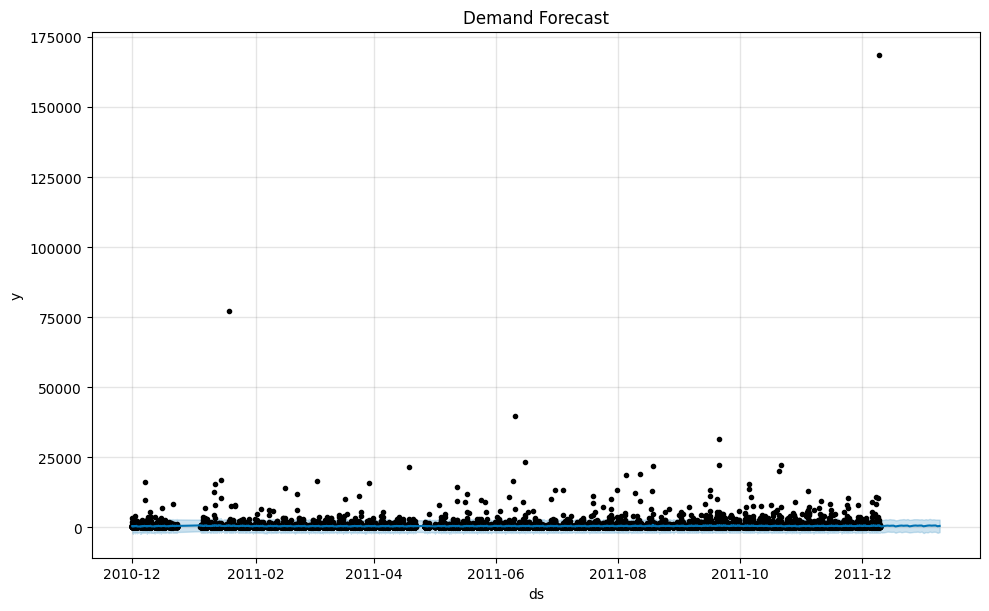

In [12]:
fig1 = model.plot(forecast)

plt.title("Demand Forecast")

plt.show()

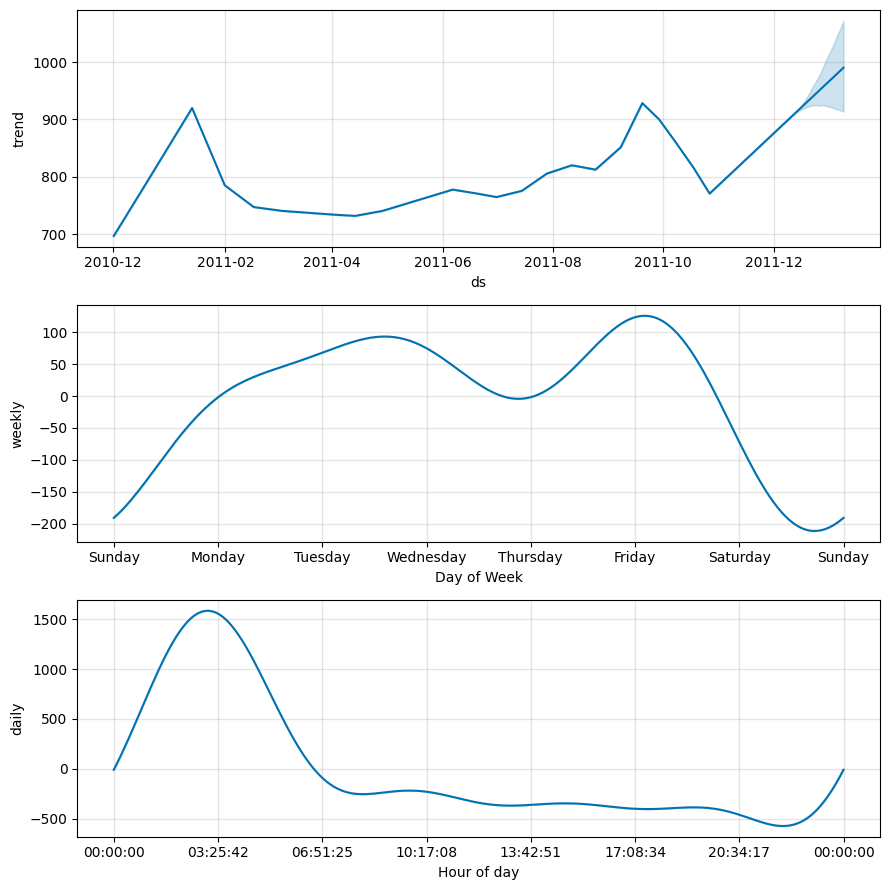

In [13]:
fig2 = model.plot_components(forecast)

plt.show()

In [14]:
forecast.to_csv("../data/sales_forecast.csv", index=False)